Parsed progress rows: 30


,step,total_steps,epoch,progress_percent,loss,grad_norm,learning_rate,elapsed_min,eta_min
0,1,30,0.1,3.33,0.618052,8.1250,0.000000,1.05,30.52
1,2,30,0.2,6.67,0.582330,6.5938,0.000020,2.01,28.17
2,3,30,0.3,10.00,0.676530,9.1250,0.000019,2.93,26.38
3,4,30,0.4,13.33,0.580712,4.3438,0.000019,3.85,25.03
4,5,30,0.5,16.67,0.527747,3.4062,0.000018,4.67,23.35


,step,total_steps,epoch,progress_percent,loss,grad_norm,learning_rate,elapsed_min,eta_min
25,26,30,2.6,86.67,0.348177,2.0625,3.448000e-06,24.90,3.83
26,27,30,2.7,90.00,0.349865,1.9531,2.759000e-06,25.82,2.87
27,28,30,2.8,93.33,0.378538,2.3125,2.069000e-06,26.61,1.90
28,29,30,2.9,96.67,0.336017,1.9688,1.379000e-06,27.32,0.94
29,30,30,3.0,100.00,0.334230,2.0156,6.897000e-07,28.24,0.00


Training runs:


,timestamp,model_id,sat_train_rows,unsat_train_rows,total_train_rows,num_train_epochs,per_device_train_batch_size,gradient_accumulation_steps,learning_rate,max_length,last_checkpoint,final_train_loss,train_runtime,train_samples_per_second,train_steps_per_second
0,2026-05-05 00:19:25,Qwen/Qwen3.5-0.8B-Base,80,80,160,3.0,1,8,0.00002,4096,NaN,0.440778,1700.4237,0.282,0.018


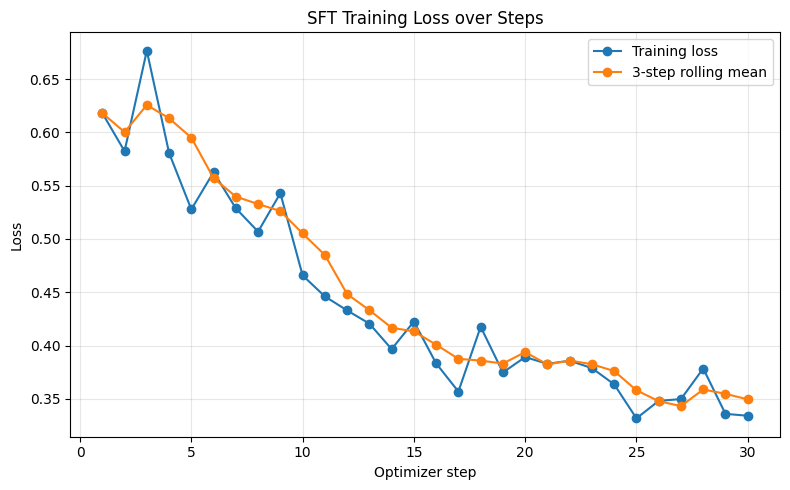

Saved: results/sft_training_plots/sft_training_loss.png


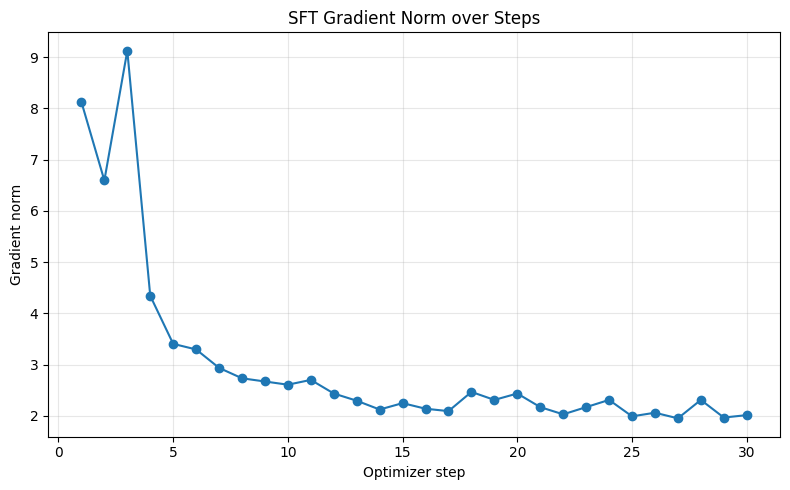

Saved: results/sft_training_plots/sft_gradient_norm.png


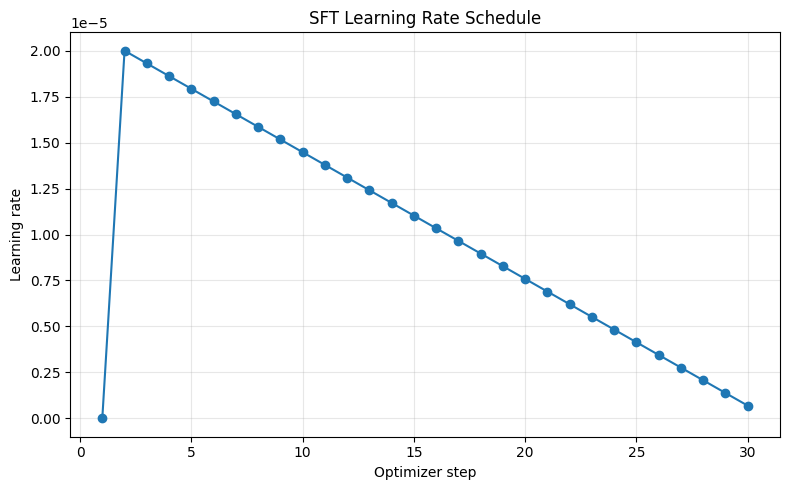

Saved: results/sft_training_plots/sft_learning_rate.png

Training summary:
{
  "model_id": "Qwen/Qwen3.5-0.8B-Base",
  "sat_train_rows": 80,
  "unsat_train_rows": 80,
  "total_train_rows": 160,
  "epochs": 3.0,
  "effective_batch_size": 8,
  "learning_rate": 2e-05,
  "max_length": 4096,
  "final_train_loss": 0.4407783091068268,
  "train_runtime_min": 28.340395,
  "train_samples_per_second": 0.282,
  "train_steps_per_second": 0.018
}
Saved: results/sft_training_plots/sft_training_summary.json
Saved: results/sft_training_plots/parsed_sft_training_progress.csv


In [5]:
import re
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. File paths
# ============================================================

# Change these paths if your files are in a different folder.
TRAINING_RUNS_CSV = Path("/scratch/network/yd1202/COS598B-project/results/sft_qwen35_08b_base_sat_unsat_full/training_runs.csv")
TRAINING_LOG = Path("nohup_sft_training.out")

OUTPUT_DIR = Path("results/sft_training_plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. Helper: clean ANSI characters from log
# ============================================================

def clean_ansi(text: str) -> str:
    """Remove ANSI escape sequences and carriage returns from terminal logs."""
    ansi_escape = re.compile(r"\x1B(?:[@-Z\\-_]|\[[0-?]*[ -/]*[@-~])")
    text = ansi_escape.sub("", text)
    text = text.replace("\r", "\n")
    return text


# ============================================================
# 3. Parse progress lines from nohup_sft_training.out
# ============================================================

def parse_training_log(log_path: Path) -> pd.DataFrame:
    raw_text = log_path.read_text(encoding="utf-8", errors="ignore")
    text = clean_ansi(raw_text)

    rows = []

    # Example line:
    # [progress] step=1/30 | epoch=0.1000 | progress=3.33% | loss=0.618052
    # | grad_norm=8.1250 | lr=0.000e+00 | elapsed=1.05 min | eta=30.52 min
    progress_pattern = re.compile(
        r"\[progress\]\s+"
        r"step=(?P<step>\d+)/(?P<total_steps>\d+)\s+\|\s+"
        r"epoch=(?P<epoch>[0-9.]+)\s+\|\s+"
        r"progress=(?P<progress>[0-9.]+)%"
        r"(?:\s+\|\s+loss=(?P<loss>[0-9.eE+-]+))?"
        r"(?:\s+\|\s+grad_norm=(?P<grad_norm>[0-9.eE+-]+))?"
        r"(?:\s+\|\s+lr=(?P<lr>[0-9.eE+-]+))?"
        r"(?:\s+\|\s+elapsed=(?P<elapsed_min>[0-9.eE+-]+)\s+min)?"
        r"(?:\s+\|\s+eta=(?P<eta_min>[0-9.eE+-]+)\s+min)?"
    )

    for match in progress_pattern.finditer(text):
        item = match.groupdict()

        def to_float(x):
            return float(x) if x not in [None, ""] else None

        rows.append({
            "step": int(item["step"]),
            "total_steps": int(item["total_steps"]),
            "epoch": to_float(item["epoch"]),
            "progress_percent": to_float(item["progress"]),
            "loss": to_float(item["loss"]),
            "grad_norm": to_float(item["grad_norm"]),
            "learning_rate": to_float(item["lr"]),
            "elapsed_min": to_float(item["elapsed_min"]),
            "eta_min": to_float(item["eta_min"]),
        })

    df = pd.DataFrame(rows)

    # Drop duplicate final progress lines if they repeat the same step without loss.
    if not df.empty:
        df = df.sort_values(["step", "loss"], na_position="last")
        df = df.drop_duplicates(subset=["step"], keep="first")
        df = df.sort_values("step").reset_index(drop=True)

    return df


progress_df = parse_training_log(TRAINING_LOG)

print("Parsed progress rows:", len(progress_df))
display(progress_df.head())
display(progress_df.tail())


# ============================================================
# 4. Load final run summary from training_runs.csv
# ============================================================

runs_df = pd.read_csv(TRAINING_RUNS_CSV)

print("Training runs:")
display(runs_df)

# Convert useful columns to numeric.
numeric_cols = [
    "sat_train_rows",
    "unsat_train_rows",
    "total_train_rows",
    "num_train_epochs",
    "per_device_train_batch_size",
    "gradient_accumulation_steps",
    "learning_rate",
    "max_length",
    "final_train_loss",
    "train_runtime",
    "train_samples_per_second",
    "train_steps_per_second",
]

for col in numeric_cols:
    if col in runs_df.columns:
        runs_df[col] = pd.to_numeric(runs_df[col], errors="coerce")


# ============================================================
# 5. Plot 1: Training loss over optimizer steps
# ============================================================

loss_df = progress_df.dropna(subset=["loss"]).copy()

plt.figure(figsize=(8, 5))
plt.plot(loss_df["step"], loss_df["loss"], marker="o", label="Training loss")

if len(loss_df) >= 3:
    loss_df["loss_rolling"] = loss_df["loss"].rolling(window=3, min_periods=1).mean()
    plt.plot(loss_df["step"], loss_df["loss_rolling"], marker="o", label="3-step rolling mean")

plt.xlabel("Optimizer step")
plt.ylabel("Loss")
plt.title("SFT Training Loss over Steps")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

loss_plot_path = OUTPUT_DIR / "sft_training_loss.png"
plt.savefig(loss_plot_path, dpi=200)
plt.show()

print("Saved:", loss_plot_path)


# ============================================================
# 6. Plot 2: Gradient norm over optimizer steps
# ============================================================

grad_df = progress_df.dropna(subset=["grad_norm"]).copy()

plt.figure(figsize=(8, 5))
plt.plot(grad_df["step"], grad_df["grad_norm"], marker="o")
plt.xlabel("Optimizer step")
plt.ylabel("Gradient norm")
plt.title("SFT Gradient Norm over Steps")
plt.grid(True, alpha=0.3)
plt.tight_layout()

grad_plot_path = OUTPUT_DIR / "sft_gradient_norm.png"
plt.savefig(grad_plot_path, dpi=200)
plt.show()

print("Saved:", grad_plot_path)


# ============================================================
# 7. Plot 3: Learning rate schedule
# ============================================================

lr_df = progress_df.dropna(subset=["learning_rate"]).copy()

plt.figure(figsize=(8, 5))
plt.plot(lr_df["step"], lr_df["learning_rate"], marker="o")
plt.xlabel("Optimizer step")
plt.ylabel("Learning rate")
plt.title("SFT Learning Rate Schedule")
plt.grid(True, alpha=0.3)
plt.tight_layout()

lr_plot_path = OUTPUT_DIR / "sft_learning_rate.png"
plt.savefig(lr_plot_path, dpi=200)
plt.show()

print("Saved:", lr_plot_path)


# # ============================================================
# # 8. Plot 4: Elapsed time over optimizer steps
# # ============================================================

# time_df = progress_df.dropna(subset=["elapsed_min"]).copy()

# plt.figure(figsize=(8, 5))
# plt.plot(time_df["step"], time_df["elapsed_min"], marker="o")
# plt.xlabel("Optimizer step")
# plt.ylabel("Elapsed time (minutes)")
# plt.title("SFT Training Time Progress")
# plt.grid(True, alpha=0.3)
# plt.tight_layout()

# time_plot_path = OUTPUT_DIR / "sft_elapsed_time.png"
# plt.savefig(time_plot_path, dpi=200)
# plt.show()

# print("Saved:", time_plot_path)


# # ============================================================
# # 9. Plot 5: Loss by epoch
# # ============================================================

# plt.figure(figsize=(8, 5))
# plt.plot(loss_df["epoch"], loss_df["loss"], marker="o", label="Training loss")

# if "loss_rolling" in loss_df.columns:
#     plt.plot(loss_df["epoch"], loss_df["loss_rolling"], marker="o", label="3-step rolling mean")

# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("SFT Training Loss by Epoch")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()

# epoch_loss_plot_path = OUTPUT_DIR / "sft_loss_by_epoch.png"
# plt.savefig(epoch_loss_plot_path, dpi=200)
# plt.show()

# print("Saved:", epoch_loss_plot_path)


# # ============================================================
# # 10. Plot 6: Dataset composition
# # ============================================================

# latest_run = runs_df.iloc[-1]

# dataset_counts = pd.Series({
#     "SAT train": latest_run.get("sat_train_rows", 0),
#     "UNSAT train": latest_run.get("unsat_train_rows", 0),
# })

# plt.figure(figsize=(6, 5))
# dataset_counts.plot(kind="bar")
# plt.xlabel("Training subset")
# plt.ylabel("Number of examples")
# plt.title("SFT Training Dataset Composition")
# plt.xticks(rotation=0)
# plt.grid(True, axis="y", alpha=0.3)
# plt.tight_layout()

# dataset_plot_path = OUTPUT_DIR / "sft_dataset_composition.png"
# plt.savefig(dataset_plot_path, dpi=200)
# plt.show()

# print("Saved:", dataset_plot_path)


# ============================================================
# 11. Print concise training summary
# ============================================================

summary = {
    "model_id": latest_run.get("model_id"),
    "sat_train_rows": int(latest_run.get("sat_train_rows")),
    "unsat_train_rows": int(latest_run.get("unsat_train_rows")),
    "total_train_rows": int(latest_run.get("total_train_rows")),
    "epochs": float(latest_run.get("num_train_epochs")),
    "effective_batch_size": int(
        latest_run.get("per_device_train_batch_size")
        * latest_run.get("gradient_accumulation_steps")
    ),
    "learning_rate": float(latest_run.get("learning_rate")),
    "max_length": int(latest_run.get("max_length")),
    "final_train_loss": float(latest_run.get("final_train_loss")),
    "train_runtime_min": float(latest_run.get("train_runtime")) / 60.0,
    "train_samples_per_second": float(latest_run.get("train_samples_per_second")),
    "train_steps_per_second": float(latest_run.get("train_steps_per_second")),
}

print("\nTraining summary:")
print(json.dumps(summary, indent=2))

summary_path = OUTPUT_DIR / "sft_training_summary.json"
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
print("Saved:", summary_path)


# ============================================================
# 12. Save parsed training progress table
# ============================================================

parsed_csv_path = OUTPUT_DIR / "parsed_sft_training_progress.csv"
progress_df.to_csv(parsed_csv_path, index=False)
print("Saved:", parsed_csv_path)

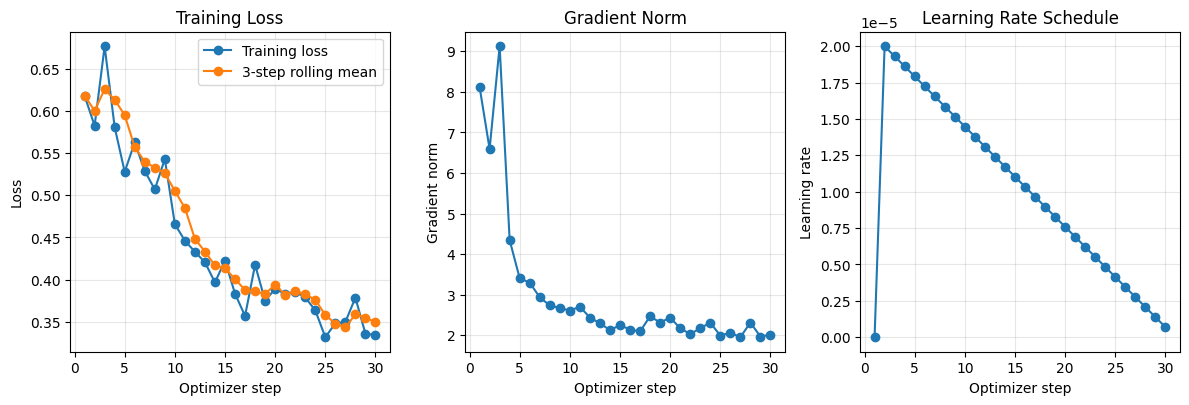

Saved: results/sft_training_plots/sft_training_three_panel.png


In [8]:
# ============================================================
# Combined plot: loss, gradient norm, and learning rate
# Three square subplots in one row
# ============================================================

loss_df = progress_df.dropna(subset=["loss"]).copy()
grad_df = progress_df.dropna(subset=["grad_norm"]).copy()
lr_df = progress_df.dropna(subset=["learning_rate"]).copy()

# Compute rolling loss if enough points
if len(loss_df) >= 3:
    loss_df["loss_rolling"] = loss_df["loss"].rolling(window=3, min_periods=1).mean()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# ----------------------------
# Subplot 1: Training loss
# ----------------------------
axes[0].plot(loss_df["step"], loss_df["loss"], marker="o", label="Training loss")

if "loss_rolling" in loss_df.columns:
    axes[0].plot(loss_df["step"], loss_df["loss_rolling"], marker="o", label="3-step rolling mean")

axes[0].set_xlabel("Optimizer step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_box_aspect(1)  # square subplot

# ----------------------------
# Subplot 2: Gradient norm
# ----------------------------
axes[1].plot(grad_df["step"], grad_df["grad_norm"], marker="o")
axes[1].set_xlabel("Optimizer step")
axes[1].set_ylabel("Gradient norm")
axes[1].set_title("Gradient Norm")
axes[1].grid(True, alpha=0.3)
axes[1].set_box_aspect(1)  # square subplot

# ----------------------------
# Subplot 3: Learning rate
# ----------------------------
axes[2].plot(lr_df["step"], lr_df["learning_rate"], marker="o")


axes[2].set_xlabel("Optimizer step")
axes[2].set_ylabel("Learning rate")
axes[2].set_title("Learning Rate Schedule")
axes[2].grid(True, alpha=0.3)
axes[2].set_box_aspect(1)  # square subplot

plt.tight_layout()

combined_plot_path = OUTPUT_DIR / "sft_training_three_panel.png"
plt.savefig(combined_plot_path, dpi=600, bbox_inches="tight")
plt.show()

print("Saved:", combined_plot_path)